In [10]:
import pandas as pd
import numpy as np

In [11]:
df = pd.read_csv('diabetes_prediction_dataset.csv')

In [12]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB
None


In [13]:
print(df.isnull().sum())

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64


In [14]:
print(df.isnull().sum())

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64


In [15]:
df = df.drop_duplicates()

In [16]:
print(f"\nShape after removing duplicates: {df.shape}")


Shape after removing duplicates: (96146, 9)


In [19]:
# Handling Categorical Values
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = ['gender', 'smoking_history']

for col in categorical_cols:
    if col in df.columns:
        df[col] = le.fit_transform(df[col])
        df[col] = df[col].astype(int)
print(df.dtypes)

gender                   int64
age                    float64
hypertension             int64
heart_disease            int64
smoking_history          int64
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object


In [20]:
#Correlation Analysis & Heatmap Insights
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
corr_matrix = df.corr()

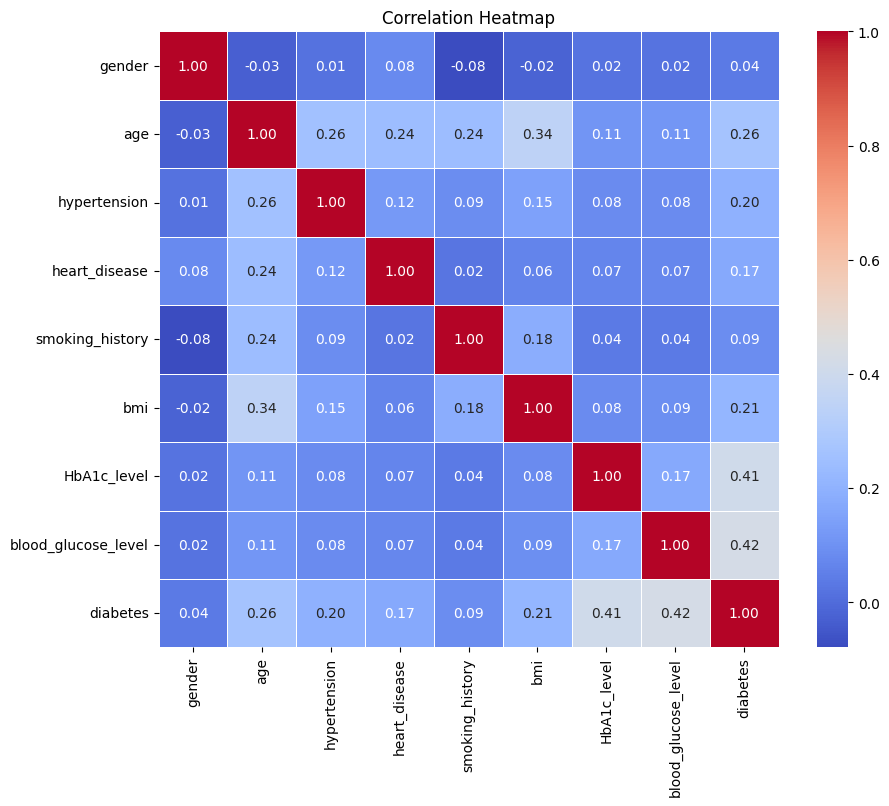

In [22]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

In [23]:
print("Correlation with Diabetes status:")
print(corr_matrix['diabetes'].sort_values(ascending=False))

Correlation with Diabetes status:
diabetes               1.000000
blood_glucose_level    0.424336
HbA1c_level            0.406408
age                    0.264927
bmi                    0.214932
hypertension           0.195710
heart_disease          0.170711
smoking_history        0.088471
gender                 0.037613
Name: diabetes, dtype: float64


In [24]:
#Model Training & Confusion Matrix
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

In [25]:
X = df.drop(columns=['diabetes'])
y = df['diabetes']

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [31]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [39]:
y_pred = model.predict(X_test)

In [38]:
cm = confusion_matrix(y_test, y_pred)

<Figure size 600x500 with 0 Axes>

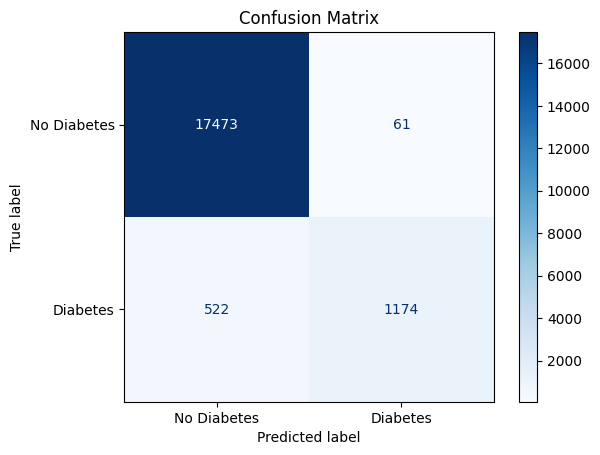

In [37]:
plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Diabetes', 'Diabetes'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix')
plt.show()

In [36]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98     17534
           1       0.95      0.69      0.80      1696

    accuracy                           0.97     19230
   macro avg       0.96      0.84      0.89     19230
weighted avg       0.97      0.97      0.97     19230



C:\Users\ASUS\AppData\Local\Temp\ipykernel_15824\1143355057.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=feature_names[indices], palette="viridis")


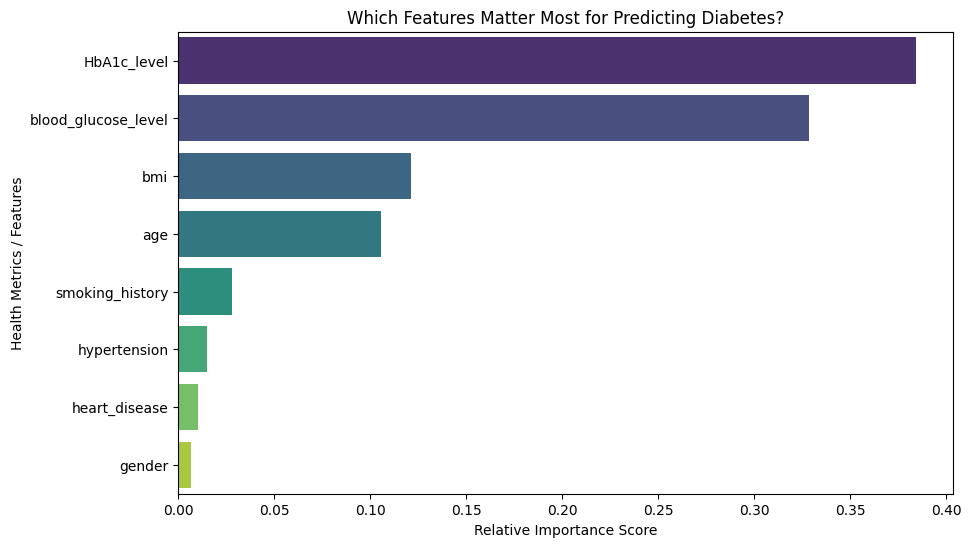

In [41]:
# Extract feature importances from our trained model
importances = model.feature_importances_
feature_names = X.columns

indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Which Features Matter Most for Predicting Diabetes?")
sns.barplot(x=importances[indices], y=feature_names[indices], palette="viridis")
plt.xlabel("Relative Importance Score")
plt.ylabel("Health Metrics / Features")
plt.show()

In [42]:
#Handling Imbalance with SMOTE (Synthetic Minority Over-sampling Technique)
!pip install imbalanced-learn


   ---------------------------------------- 0/2 [sklearn-compat]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   ---------------------------------------- 2/2 [imbalanced-learn]




[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [44]:
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix

# Initialize SMOTE
smote = SMOTE(random_state=42)

X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"Original training shape: {y_train.value_counts().to_dict()}")
print(f"Balanced training shape: {y_train_balanced.value_counts().to_dict()}")

balanced_model = RandomForestClassifier(random_state=42)
balanced_model.fit(X_train_balanced, y_train_balanced)

y_pred_balanced = balanced_model.predict(X_test)

print(classification_report(y_test, y_pred_balanced))

Original training shape: {0: 70130, 1: 6786}
Balanced training shape: {0: 70130, 1: 70130}
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     17534
           1       0.77      0.75      0.76      1696

    accuracy                           0.96     19230
   macro avg       0.87      0.86      0.87     19230
weighted avg       0.96      0.96      0.96     19230

